In [1]:
import pandas as pd
import numpy as np
import os

# Create a sample billboard impact dataset based on the description
np.random.seed(42)

# Generate sample data
n_obs_per_group = 100  # observations per city per period

# Pre-treatment (May) - baseline deposits
may_florianopolis = np.random.normal(1000, 150, n_obs_per_group)  # Control city pre-treatment
may_porto_alegre = np.random.normal(1100, 150, n_obs_per_group)  # Treatment city pre-treatment

# Post-treatment (July) - with treatment effect
jul_florianopolis = np.random.normal(1050, 150, n_obs_per_group)  # Control city post-treatment (natural growth)
jul_porto_alegre = np.random.normal(1300, 150, n_obs_per_group)  # Treatment city post-treatment (with billboard effect)

# Create dataframe
data = []
for i in range(n_obs_per_group):
    # Florianopolis May (Control, Pre)
    data.append({'deposits': may_florianopolis[i], 'poa': 0, 'jul': 0})
    # Florianopolis July (Control, Post)
    data.append({'deposits': jul_florianopolis[i], 'poa': 0, 'jul': 1})
    # Porto Alegre May (Treatment, Pre)
    data.append({'deposits': may_porto_alegre[i], 'poa': 1, 'jul': 0})
    # Porto Alegre July (Treatment, Post)
    data.append({'deposits': jul_porto_alegre[i], 'poa': 1, 'jul': 1})

df = pd.DataFrame(data)

# Create the directory if it doesn't exist
os.makedirs('/Users/vishal/Projects/causal-agent/data/all_data', exist_ok=True)

# Save the dataset
df.to_csv('/Users/vishal/Projects/causal-agent/data/all_data/billboard_impact.csv', index=False)

print("Dataset created successfully!")
print(f"Shape: {df.shape}")
print("\nFirst few rows:")
print(df.head())
print("\nSummary statistics:")
print(df.describe())

Dataset created successfully!
Shape: (400, 3)

First few rows:
      deposits  poa  jul
0  1074.507123    0    0
1  1103.668104    0    1
2   887.694389    1    0
3  1175.650748    1    1
4   979.260355    0    0

Summary statistics:
          deposits         poa         jul
count   400.000000  400.000000  400.000000
mean   1115.882292    0.500000    0.500000
std     189.232904    0.500626    0.500626
min     563.809899    0.000000    0.000000
25%     971.969957    0.000000    0.000000
50%    1118.593615    0.500000    0.500000
75%    1225.469542    1.000000    1.000000
max    1628.470440    1.000000    1.000000


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import json
import os
from datetime import datetime

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the dataset
data_path = "/Users/vishal/Projects/causal-agent/data/all_data/billboard_impact.csv"
df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

Dataset shape: (400, 3)

First few rows:
      deposits  poa  jul
0  1074.507123    0    0
1  1103.668104    0    1
2   887.694389    1    0
3  1175.650748    1    1
4   979.260355    0    0


In [3]:
# Data quality assessment
print("=== DATA QUALITY ASSESSMENT ===")
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nSummary statistics:")
print(df.describe())

# Check unique values for categorical variables
print("\nUnique values for poa (treatment indicator):", df['poa'].unique())
print("Unique values for jul (time indicator):", df['jul'].unique())

# Check balance of groups
print("\nGroup sizes:")
print("Pre-intervention (jul=0):", df[df['jul']==0].shape[0])
print("Post-intervention (jul=1):", df[df['jul']==1].shape[0])
print("Control city (poa=0):", df[df['poa']==0].shape[0])
print("Treatment city (poa=1):", df[df['poa']==1].shape[0])

# Cross-tabulation
print("\nCross-tabulation of treatment and time:")
print(pd.crosstab(df['poa'], df['jul'], margins=True))

=== DATA QUALITY ASSESSMENT ===

Data types:
deposits    float64
poa           int64
jul           int64
dtype: object

Missing values:
deposits    0
poa         0
jul         0
dtype: int64

Summary statistics:
          deposits         poa         jul
count   400.000000  400.000000  400.000000
mean   1115.882292    0.500000    0.500000
std     189.232904    0.500626    0.500626
min     563.809899    0.000000    0.000000
25%     971.969957    0.000000    0.000000
50%    1118.593615    0.500000    0.500000
75%    1225.469542    1.000000    1.000000
max    1628.470440    1.000000    1.000000

Unique values for poa (treatment indicator): [0 1]
Unique values for jul (time indicator): [0 1]

Group sizes:
Pre-intervention (jul=0): 200
Post-intervention (jul=1): 200
Control city (poa=0): 200
Treatment city (poa=1): 200

Cross-tabulation of treatment and time:
jul    0    1  All
poa               
0    100  100  200
1    100  100  200
All  200  200  400


=== DISTRIBUTION ANALYSIS ===

Deposits by group:
         count         mean         std         min          max       median
poa jul                                                                      
0   0      100   984.423022  136.225264  607.038234  1277.841728   980.956556
    1      100  1059.734438  162.642432  563.809899  1627.909724  1064.654361
1   0      100  1103.345688  143.050345  812.184318  1508.025375  1112.616075
    1      100  1316.026018  132.615212  981.415641  1628.470440  1307.523605


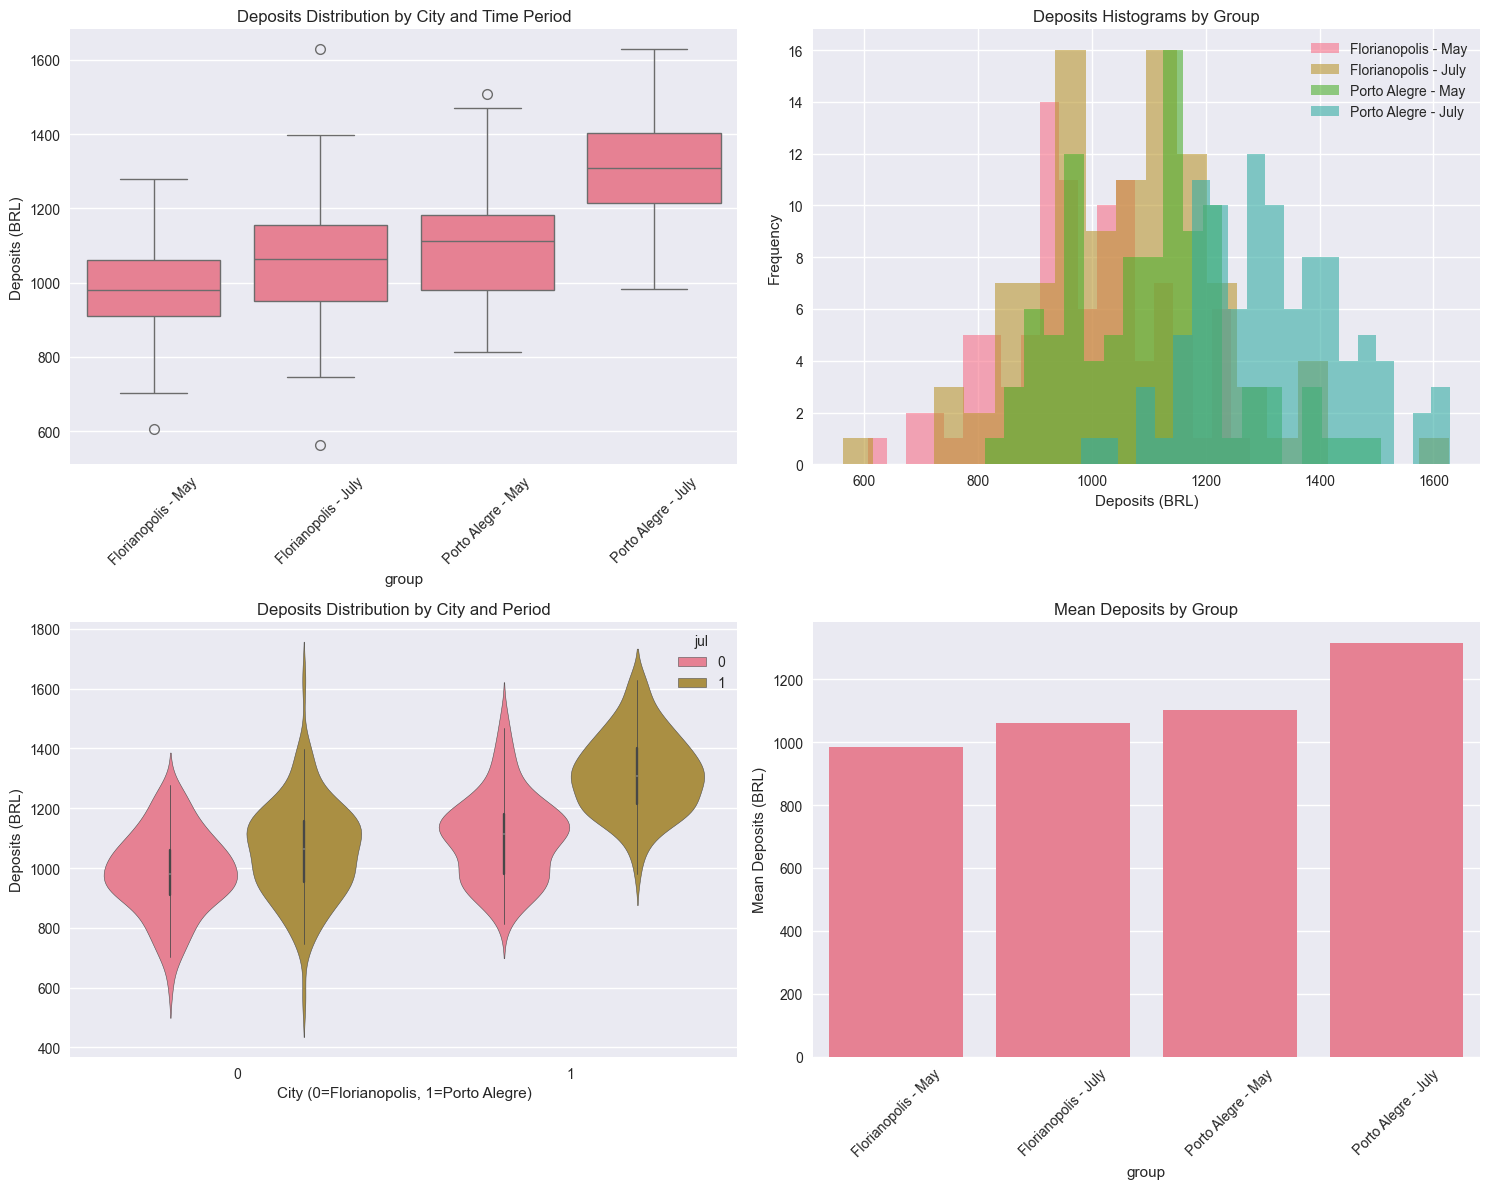


Normality tests by group:
Florianopolis - May: Shapiro-Wilk p-value = 0.6552 (Normal)
Florianopolis - July: Shapiro-Wilk p-value = 0.3551 (Normal)
Porto Alegre - May: Shapiro-Wilk p-value = 0.0853 (Normal)
Porto Alegre - July: Shapiro-Wilk p-value = 0.6578 (Normal)


In [4]:
# Distribution analysis of deposits by city and time period
print("=== DISTRIBUTION ANALYSIS ===")

# Create group labels for better visualization
df['group'] = df.apply(lambda row: f"{'Porto Alegre' if row['poa']==1 else 'Florianopolis'} - {'July' if row['jul']==1 else 'May'}", axis=1)

# Summary statistics by group
group_stats = df.groupby(['poa', 'jul'])['deposits'].agg(['count', 'mean', 'std', 'min', 'max', 'median'])
print("\nDeposits by group:")
print(group_stats)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Box plots by group
sns.boxplot(data=df, x='group', y='deposits', ax=axes[0,0])
axes[0,0].set_title('Deposits Distribution by City and Time Period')
axes[0,0].set_ylabel('Deposits (BRL)')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Histograms by group
for group in df['group'].unique():
    subset = df[df['group'] == group]
    axes[0,1].hist(subset['deposits'], alpha=0.6, label=group, bins=20)
axes[0,1].set_title('Deposits Histograms by Group')
axes[0,1].set_xlabel('Deposits (BRL)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend()

# 3. Violin plots
sns.violinplot(data=df, x='poa', y='deposits', hue='jul', ax=axes[1,0])
axes[1,0].set_title('Deposits Distribution by City and Period')
axes[1,0].set_xlabel('City (0=Florianopolis, 1=Porto Alegre)')
axes[1,0].set_ylabel('Deposits (BRL)')

# 4. Mean comparison bar chart
means = df.groupby(['poa', 'jul'])['deposits'].mean().reset_index()
means['group'] = means.apply(lambda row: f"{'Porto Alegre' if row['poa']==1 else 'Florianopolis'} - {'July' if row['jul']==1 else 'May'}", axis=1)
sns.barplot(data=means, x='group', y='deposits', ax=axes[1,1])
axes[1,1].set_title('Mean Deposits by Group')
axes[1,1].set_ylabel('Mean Deposits (BRL)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/deposits_distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistical tests for normality
print("\nNormality tests by group:")
for group in df['group'].unique():
    subset = df[df['group'] == group]['deposits']
    stat, p_value = stats.shapiro(subset)
    print(f"{group}: Shapiro-Wilk p-value = {p_value:.4f} {'(Normal)' if p_value > 0.05 else '(Not Normal)'}")

=== PRE-INTERVENTION BALANCE CHECKS ===

Pre-intervention summary by city:
     count         mean         std       median
poa                                             
0      100   984.423022  136.225264   980.956556
1      100  1103.345688  143.050345  1112.616075

Pre-intervention t-test:
T-statistic: -6.0203
P-value: 0.0000
Mean difference: 118.92 BRL
Cohen's d (effect size): 0.8514


/var/folders/mk/0g2nrd0112g6vnrpxzc0ffb80000gp/T/ipykernel_18243/261427599.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(['Florianopolis', 'Porto Alegre'])


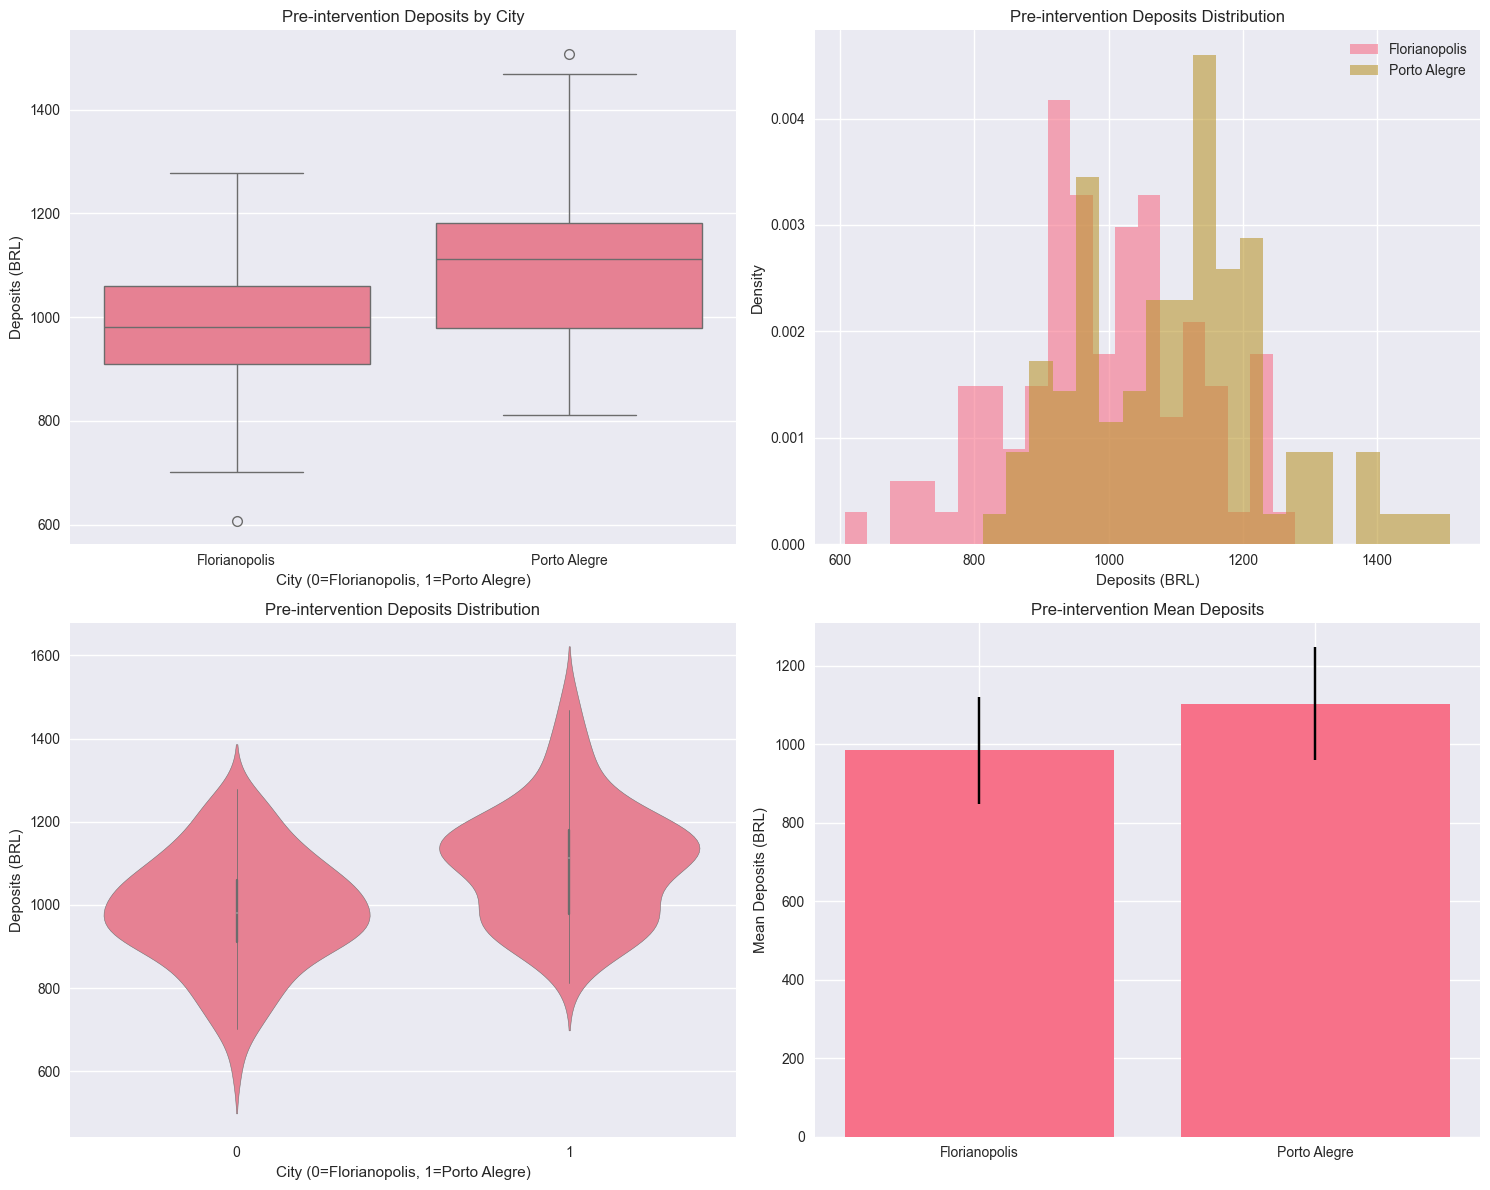


Pre-intervention balance metrics:
Control mean: 984.42 (SD: 136.23)
Treatment mean: 1103.35 (SD: 143.05)
Standardized difference: 0.8514


In [5]:
# Balance checks between treatment and control groups pre-intervention
print("=== PRE-INTERVENTION BALANCE CHECKS ===")

# Pre-intervention data (jul=0)
pre_data = df[df['jul'] == 0]

# Summary statistics by city pre-intervention
pre_balance = pre_data.groupby('poa')['deposits'].agg(['count', 'mean', 'std', 'median'])
print("\nPre-intervention summary by city:")
print(pre_balance)

# Statistical test for difference pre-intervention
control_pre = pre_data[pre_data['poa'] == 0]['deposits']
treatment_pre = pre_data[pre_data['poa'] == 1]['deposits']

# T-test for equality of means pre-intervention
t_stat, p_value = stats.ttest_ind(control_pre, treatment_pre)
print(f"\nPre-intervention t-test:")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Mean difference: {treatment_pre.mean() - control_pre.mean():.2f} BRL")

# Effect size (Cohen's d)
pooled_std = np.sqrt(((len(control_pre) - 1) * control_pre.var() + (len(treatment_pre) - 1) * treatment_pre.var()) / 
                    (len(control_pre) + len(treatment_pre) - 2))
cohens_d = (treatment_pre.mean() - control_pre.mean()) / pooled_std
print(f"Cohen's d (effect size): {cohens_d:.4f}")

# Create balance visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Pre-intervention boxplot
sns.boxplot(data=pre_data, x='poa', y='deposits', ax=axes[0,0])
axes[0,0].set_title('Pre-intervention Deposits by City')
axes[0,0].set_xlabel('City (0=Florianopolis, 1=Porto Alegre)')
axes[0,0].set_ylabel('Deposits (BRL)')
axes[0,0].set_xticklabels(['Florianopolis', 'Porto Alegre'])

# 2. Pre-intervention histograms
axes[0,1].hist(control_pre, alpha=0.6, label='Florianopolis', bins=20, density=True)
axes[0,1].hist(treatment_pre, alpha=0.6, label='Porto Alegre', bins=20, density=True)
axes[0,1].set_title('Pre-intervention Deposits Distribution')
axes[0,1].set_xlabel('Deposits (BRL)')
axes[0,1].set_ylabel('Density')
axes[0,1].legend()

# 3. Pre-intervention violin plot
sns.violinplot(data=pre_data, x='poa', y='deposits', ax=axes[1,0])
axes[1,0].set_title('Pre-intervention Deposits Distribution')
axes[1,0].set_xlabel('City (0=Florianopolis, 1=Porto Alegre)')
axes[1,0].set_ylabel('Deposits (BRL)')

# 4. Mean comparison with error bars
means = pre_data.groupby('poa')['deposits'].mean()
stds = pre_data.groupby('poa')['deposits'].std()
axes[1,1].bar(['Florianopolis', 'Porto Alegre'], [means[0], means[1]], 
                yerr=[stds[0], stds[1]], capsize=5)
axes[1,1].set_title('Pre-intervention Mean Deposits')
axes[1,1].set_ylabel('Mean Deposits (BRL)')

plt.tight_layout()
plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/pre_intervention_balance.png', dpi=300, bbox_inches='tight')
plt.show()

# Additional balance metrics
print(f"\nPre-intervention balance metrics:")
print(f"Control mean: {control_pre.mean():.2f} (SD: {control_pre.std():.2f})")
print(f"Treatment mean: {treatment_pre.mean():.2f} (SD: {treatment_pre.std():.2f})")
print(f"Standardized difference: {abs(treatment_pre.mean() - control_pre.mean()) / np.sqrt((control_pre.var() + treatment_pre.var())/2):.4f}")